# EDA Redundant Pair Compare Raw

전처리 이전(raw에 가까운) 이중화 계량기쌍 `P` 비교 노트북입니다. 기본 대상은 `H1.Z20`와 `H1.ZE20`입니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path('/home/playdata2/final_pj/energy-platform')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from config.meter_metadata import get_all_meters, get_metadata, get_redundant_pair
from scripts.preprocess_h1z16 import fetch_joined_data

candidate_pairs = []
seen = set()
for meter_urn in get_all_meters():
    pair = get_redundant_pair(meter_urn)
    if not pair:
        continue
    pair_key = tuple(sorted([meter_urn, pair]))
    if pair_key in seen:
        continue
    seen.add(pair_key)
    candidate_pairs.append({
        'main_meter': meter_urn,
        'pair_meter': pair,
        'main_desc': get_metadata(meter_urn).get('description'),
        'pair_desc': get_metadata(pair).get('description'),
    })
candidate_pairs_df = pd.DataFrame(candidate_pairs)
display(candidate_pairs_df)

MAIN_METER_URN = 'H1.Z20'
PAIR_METER_URN = get_redundant_pair(MAIN_METER_URN)
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'redundant_pair_compare_raw'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print('main meter:', MAIN_METER_URN)
print('pair meter:', PAIR_METER_URN)
print('main metadata:', get_metadata(MAIN_METER_URN))
print('pair metadata:', get_metadata(PAIR_METER_URN))

,main_meter,pair_meter,main_desc,pair_desc
0,H1.Z20,H1.ZE20,CHP 메인,CHP redundant
1,V.Z84,V.ZE84,PV 그룹1&2 메인,PV 그룹1&2 redundant
2,H2.Z66,H2.ZE66,Workshop 로컬 냉각기1 메인,Workshop 로컬 냉각기1 redundant
3,H2.Z67,H2.ZE67,Workshop 로컬 냉각기2 메인,Workshop 로컬 냉각기2 redundant
4,H2.Z35,H2.Z351,Transformer,Transformer redundant
5,H2.Z36,H2.Z361,Transformer,Transformer redundant
6,H2.Z64,H2.ZE64,Server,Server redundant
7,H2.Z65,H2.ZE65,Server,Server redundant
8,H3.Z43,H3.ZE43,Server,Server redundant
9,H3.Z44,H3.ZE44,Server,Server redundant


main meter: H1.Z20
pair meter: H1.ZE20
main metadata: {'meter_type': 'electric', 'energy_type': 'production', 'thermal_mode': None, 'anomaly_target': 'P', 'group_name': 'chp', 'redundant_pair': 'H1.ZE20', 'description': 'CHP 메인'}
pair metadata: {'meter_type': 'electric', 'energy_type': 'production', 'thermal_mode': None, 'anomaly_target': 'P', 'group_name': 'chp', 'redundant_pair': 'H1.Z20', 'description': 'CHP redundant'}


## 1. Raw 데이터 로드

In [2]:
main_df = fetch_joined_data(MAIN_METER_URN)
pair_df = fetch_joined_data(PAIR_METER_URN)

compare_df = (
    main_df[['ts', 'P']]
    .rename(columns={'P': f'P_{MAIN_METER_URN}'})
    .merge(
        pair_df[['ts', 'P']].rename(columns={'P': f'P_{PAIR_METER_URN}'}),
        on='ts',
        how='inner',
    )
    .sort_values('ts')
    .reset_index(drop=True)
)

compare_df['signed_diff'] = compare_df[f'P_{MAIN_METER_URN}'] - compare_df[f'P_{PAIR_METER_URN}']
compare_df['abs_diff'] = compare_df['signed_diff'].abs()
denom = compare_df[[f'P_{MAIN_METER_URN}', f'P_{PAIR_METER_URN}']].abs().max(axis=1)
compare_df['rel_diff_pct'] = np.where(denom > 0, compare_df['abs_diff'] / denom * 100, np.nan)

print('main rows:', len(main_df))
print('pair rows:', len(pair_df))
print('common rows:', len(compare_df))
display(compare_df.head())

main rows: 52585
pair rows: 9519
common rows: 9519


,ts,P_H1.Z20,P_H1.ZE20,signed_diff,abs_diff,rel_diff_pct
0,2022-11-30 08:00:00+00:00,73.188667,71.572341,1.616325,1.616325,2.208437
1,2022-11-30 09:00:00+00:00,72.569583,71.382161,1.187422,1.187422,1.636254
2,2022-11-30 10:00:00+00:00,73.058500,70.996900,2.061600,2.061600,2.821848
3,2022-11-30 11:00:00+00:00,75.106333,71.279703,3.826630,3.826630,5.094950
4,2022-11-30 12:00:00+00:00,-13240.171167,-13152.677459,-87.493708,87.493708,0.660820


## 2. Raw 기초 수치 비교

In [3]:
corr = compare_df[[f'P_{MAIN_METER_URN}', f'P_{PAIR_METER_URN}']].corr().iloc[0, 1]
summary_df = pd.DataFrame([
    {
        'main_meter_urn': MAIN_METER_URN,
        'pair_meter_urn': PAIR_METER_URN,
        'common_rows': len(compare_df),
        'main_mean_P': compare_df[f'P_{MAIN_METER_URN}'].mean(),
        'pair_mean_P': compare_df[f'P_{PAIR_METER_URN}'].mean(),
        'mean_abs_diff': compare_df['abs_diff'].mean(),
        'median_abs_diff': compare_df['abs_diff'].median(),
        'max_abs_diff': compare_df['abs_diff'].max(),
        'mean_rel_diff_pct': compare_df['rel_diff_pct'].mean(),
        'p95_rel_diff_pct': compare_df['rel_diff_pct'].quantile(0.95),
        'corr': corr,
    }
])
display(summary_df)

top_diff_df = compare_df.sort_values('abs_diff', ascending=False)[[
    'ts',
    f'P_{MAIN_METER_URN}',
    f'P_{PAIR_METER_URN}',
    'signed_diff',
    'abs_diff',
    'rel_diff_pct',
]].head(10)
display(top_diff_df)

summary_path = OUTPUT_DIR / f'{MAIN_METER_URN.replace('.', '_')}__{PAIR_METER_URN.replace('.', '_')}_raw_summary.csv'
top_diff_path = OUTPUT_DIR / f'{MAIN_METER_URN.replace('.', '_')}__{PAIR_METER_URN.replace('.', '_')}_raw_top_diff.csv'
summary_df.to_csv(summary_path, index=False, encoding='utf-8-sig')
top_diff_df.to_csv(top_diff_path, index=False, encoding='utf-8-sig')
print('saved:', summary_path)
print('saved:', top_diff_path)

,main_meter_urn,pair_meter_urn,common_rows,main_mean_P,pair_mean_P,mean_abs_diff,median_abs_diff,max_abs_diff,mean_rel_diff_pct,p95_rel_diff_pct,corr
0,H1.Z20,H1.ZE20,9519,-70982.450669,-71350.80735,1811.945722,61.858633,185441.828343,3.629352,12.131333,0.988792


,ts,P_H1.Z20,P_H1.ZE20,signed_diff,abs_diff,rel_diff_pct
6597,2023-09-01 05:00:00+00:00,1088.724583,-184353.103760,185441.828343,185441.828343,100.590565
6579,2023-08-31 11:00:00+00:00,79.609750,-183989.392471,184069.002221,184069.002221,100.043269
6587,2023-08-31 19:00:00+00:00,79.710167,-180098.072509,180177.782676,180177.782676,100.044259
6331,2023-08-21 03:00:00+00:00,79.989167,-176432.804129,176512.793295,176512.793295,100.045337
6739,2023-09-07 03:00:00+00:00,-156603.435035,78.386046,-156681.821081,156681.821081,100.050054
6609,2023-09-01 17:00:00+00:00,80.171167,-156301.855039,156382.026206,156382.026206,100.051293
8010,2023-10-30 02:00:00+00:00,80.248423,-148345.508444,148425.756867,148425.756867,100.054096
8009,2023-10-30 01:00:00+00:00,80.008000,-148169.979388,148249.987388,148249.987388,100.053997
8011,2023-10-30 03:00:00+00:00,80.352167,-148145.051398,148225.403564,148225.403564,100.054239
8012,2023-10-30 04:00:00+00:00,80.579667,-147654.123566,147734.703232,147734.703232,100.054573


saved: /home/playdata2/final_pj/energy-platform/outputs/redundant_pair_compare_raw/H1_Z20__H1_ZE20_raw_summary.csv
saved: /home/playdata2/final_pj/energy-platform/outputs/redundant_pair_compare_raw/H1_Z20__H1_ZE20_raw_top_diff.csv


## 3. Raw 시계열 비교

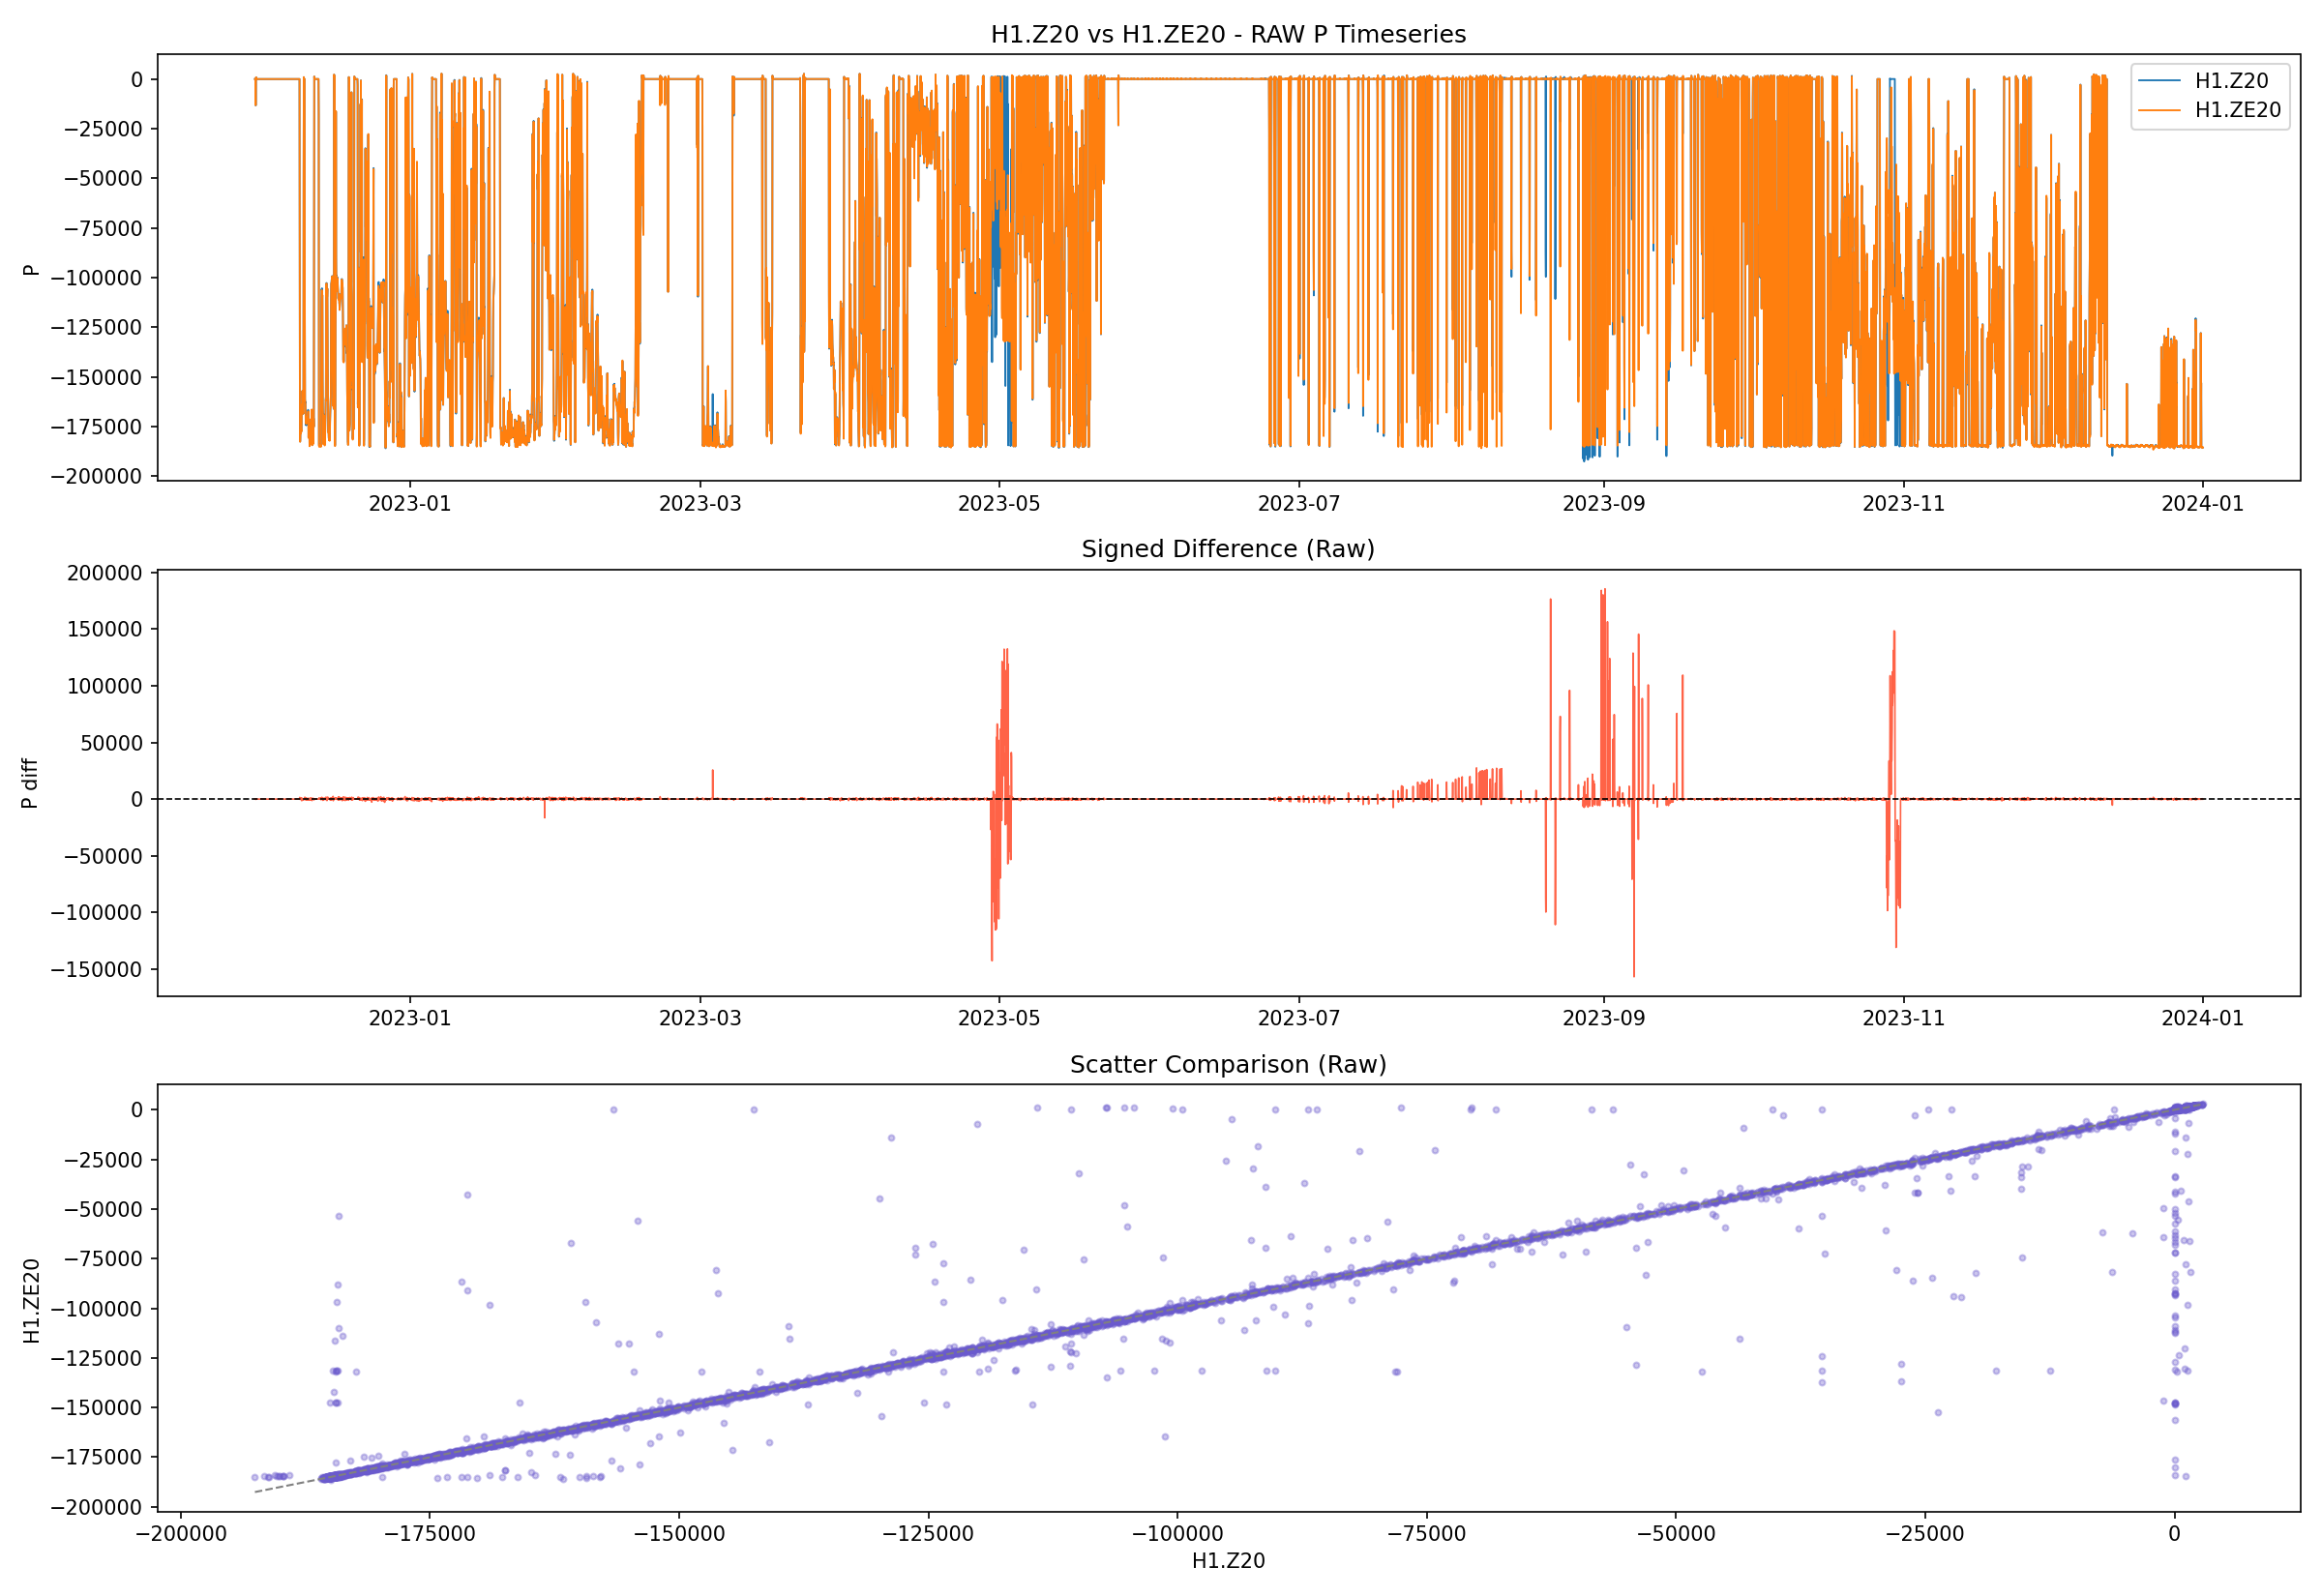

saved: /home/playdata2/final_pj/energy-platform/outputs/redundant_pair_compare_raw/H1_Z20__H1_ZE20_raw_P_compare.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=False)
axes[0].plot(compare_df['ts'], compare_df[f'P_{MAIN_METER_URN}'], label=MAIN_METER_URN, linewidth=0.9)
axes[0].plot(compare_df['ts'], compare_df[f'P_{PAIR_METER_URN}'], label=PAIR_METER_URN, linewidth=0.9)
axes[0].set_title(f'{MAIN_METER_URN} vs {PAIR_METER_URN} - RAW P Timeseries')
axes[0].set_ylabel('P')
axes[0].legend()

axes[1].plot(compare_df['ts'], compare_df['signed_diff'], color='tomato', linewidth=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('Signed Difference (Raw)')
axes[1].set_ylabel('P diff')

axes[2].scatter(compare_df[f'P_{MAIN_METER_URN}'], compare_df[f'P_{PAIR_METER_URN}'], s=8, alpha=0.35, color='slateblue')
min_val = float(min(compare_df[f'P_{MAIN_METER_URN}'].min(), compare_df[f'P_{PAIR_METER_URN}'].min()))
max_val = float(max(compare_df[f'P_{MAIN_METER_URN}'].max(), compare_df[f'P_{PAIR_METER_URN}'].max()))
axes[2].plot([min_val, max_val], [min_val, max_val], color='gray', linestyle='--', linewidth=1)
axes[2].set_title('Scatter Comparison (Raw)')
axes[2].set_xlabel(MAIN_METER_URN)
axes[2].set_ylabel(PAIR_METER_URN)

plt.tight_layout()
plot_path = OUTPUT_DIR / f'{MAIN_METER_URN.replace('.', '_')}__{PAIR_METER_URN.replace('.', '_')}_raw_P_compare.png'
plt.savefig(plot_path, dpi=150)
plt.close(fig)
display(Image(filename=str(plot_path)))
print('saved:', plot_path)